# Débruitage de Vuvuzela



In [2]:
from numpy import *
from matplotlib.pyplot import * 
import scipy.signal as signal
from scipy.io import wavfile
from IPython import *


## Introduction

### Contexte / Problématique

Lors de la coupe du Monde de Football 2010, les téléspectateurs du monde entier ont pu découvrir un instrument de musique d’Afrique du Sud : le Vuvuzela. Passé la phase d’étonnement, le son continu généré par cet instrument est rapidement devenu gênant lors de la diffusion des matchs ([youtube](https://www.youtube.com/watch?v=bKCIFXqhLzo)). Dans ce projet, nous allons mettre en place un filtre "anti-vuvuzela" pour atténuer les sonorités de cet instrument.

<figure style="padding:40px;align:center">
<img style="width: 400px" src="https://i.dailymail.co.uk/i/pix/2010/06/13/article-1286265-09FE0925000005DC-48_468x299.jpg">
</figure>

### Méthodologie

In [3]:
Fs,data = wavfile.read("wav/vuvuzela.wav")     #read wavefile
data = data/(1.1*max(abs(data)))               # normalisation
#Audio(data,rate=Fs)

Le repo gitlab contient un enregistrement sonore nommé `vuvuzela.wav` dans le repertoire `wav`. Cet enregistrement a été réalisé lors d’un match de la coupe du monde 2010. Pour supprimer les sonorités de Vuvuzela, nous allons procéder de la manière suivante :

1. Analyse du contenu spectral du fichier `vuvuzela.wav`. Identification des fréquences à rejeter.
2. Analyse et étude expérimentale de différents "rejecteurs" :`
    * un filtre RLC,
    * un filtre Twin T passif,
    * un filtre Twin T actif.
3. Simulation avec python et LTSpice de la structure sélectionnée. Mise en cascade des filtres.
4. Câblage de la cascade et test de l’ensemble sur le signal audio fourni.

Pour chacune de ces étapes, les analyses et résultats expérimentaux devront apparaître dans le notebook Jupyter en expliquant et justifiant votre démarche.

## Analyse Spectrale


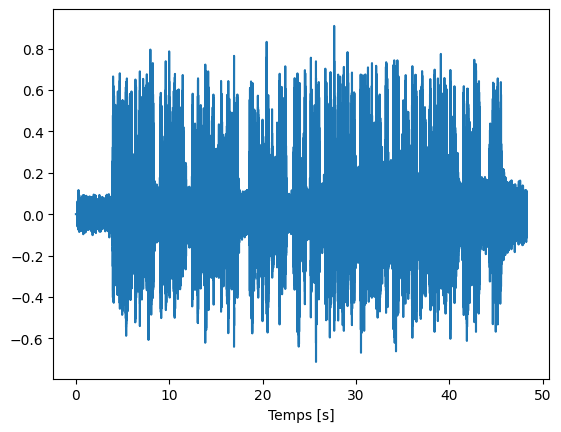

In [4]:
t = arange(len(data))/Fs         #convert sample index to time (in sec)
plot(t,data)
xlabel("Temps [s]");

La figure précédente affiche la représentation temporelle de l'enregistrement sonore à débruiter. Cet enregistrement contient des parties contenant uniquement les sonorités de Vuvuzela (entre 0 et 2s par exemple) et d'autres parties contenant les sonorités de Vuvuzela ainsi que des commentaires de journalistes sportifs.
Mathématiquement, les sonorités de Vuvuzela peuvent être modélisés par une somme de plusieurs sinusoïdes de fréquence $f_l$ c-a-d

$$x(t) = \sum_{l=1}^L a_l sin(2\pi f_l l t + \varphi_l)$$

Dans un premier temps, il est nécessaire de déterminer les fréquences $f_1$,$\cdots$, $f_L$ en réalisant une analyse spectrale (c-a-d fréquentielle) de l’enregistrement sonore. L'analyse pourra être réalisée en utilisant Python. Ccette partie nécessitera d’utiliser la fonctionnalité suivante :

* Estimation du spectre: [Documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html)

En utilisant `python`, représentez le contenu temporel puis fréquentiel de l'enregistrement sonore.

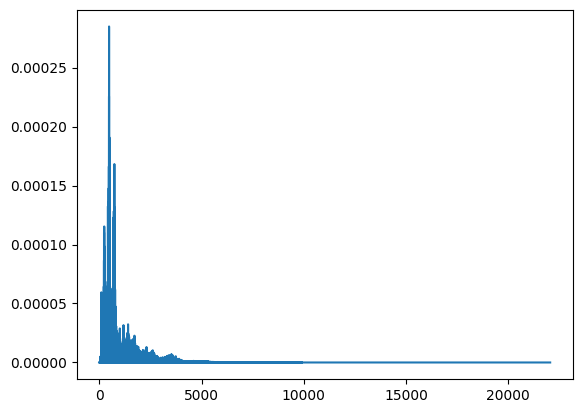

In [5]:
%matplotlib inline
f,Pxx=signal.periodogram(data,Fs)
plot(f,Pxx)

Isolez une portion temporelle de l’enregistrement sonore ne contenant que des sonorités de Vuvuzela (pas de commentaires sportifs). Représentez alors le contenu fréquentiel de cette portion.



154350.0


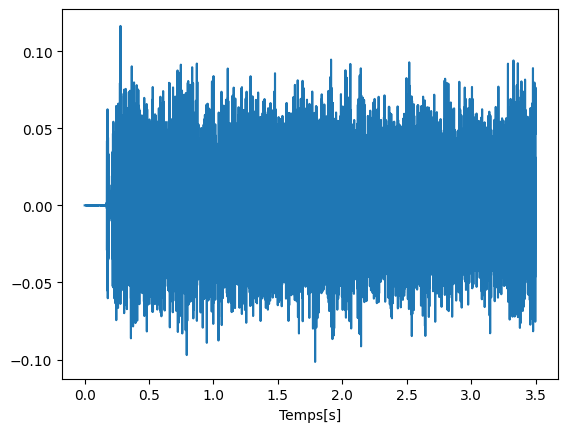

In [6]:
%matplotlib inline
n=Fs*3.5
print(n)
wavfile.write("vuvuzela_only.wav", Fs,data[0:int(Fs*3.5)])
Fs,data_v=wavfile.read("vuvuzela_only.wav")
t = arange(len(data_v))/Fs
plot(t,data_v)
xlabel("Temps[s]");

Identifiez les composantes fréquentielles du son de Vuvuzela c-a-d les valeurs de $f_l$ ($k = 1,\cdots,L$). Retrouvez alors l'unique note de la gamme tempérée qu'est capable de générer le Vuvuzela.

le max est 819.0


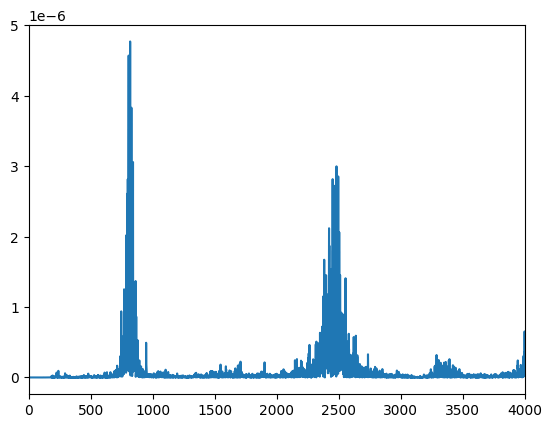

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
f,Pxx=signal.periodogram(data_v,int(Fs*3.5))
plot(f,Pxx)
plt.xlim(0.0,4000)
indice_max=np.argmax(Pxx)
max_x=f[indice_max]
print(f"le max est {max_x}")

## Filtre rejecteur RLC

Dans un premier temps, nous allons considérer le rejecteur RLC suivant :

<figure style="padding:40px;align:center">
<img style="width: 250px" src="./img/RLC.png">
<figcaption style='text-align:center;padding-top:20px;font-style: italic;'>Fig. Filtre RLC</figcaption>
</figure>

## Filtre rejecteur Twin-T

Pour éviter d’utiliser plusieurs bobines, nous allons maintenant considérer un filtre rejecteur Twin-T passif. Ce filtre est décrit dans la figure suivante :

<figure style="padding:40px;align:center">
<img style="width: 250px" src="./img/twinT.png">
<figcaption style='text-align:center;padding-top:20px;font-style: italic;'>Fig. Filtre Twin-T</figcaption>
</figure>

## Filtre rejecteur Twin-T actif

Le filtre précédent ne permet pas d'obtenir des résultats sonores satisfaisants. Pour améliorer le résultat sonore, il est possible d'utiliser un filtre Twin-T actif. Contrairement au filtre Twin-T passif, le filtre Twin-T actif permet le contrôle du coefficient d'amortissement $m$. Le tutoriel [MT-225 d’Analog Devices](https://www.analog.com/media/en/training-seminars/tutorials/MT-225.pdf) décrit la structure de ce filtre et donne plusieurs recommandations pour choisir les composants.